# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [2]:
# Import the library
from PIL import Image,ImageOps
import numpy as np


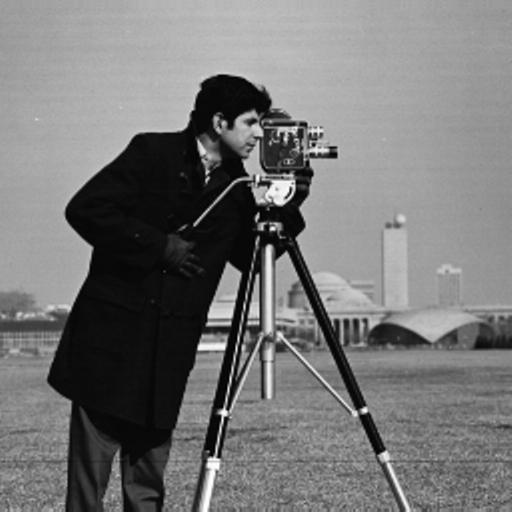

In [3]:
# ── Load image ────────────────────────────────────
img=Image.open("cameraman.jpg")
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

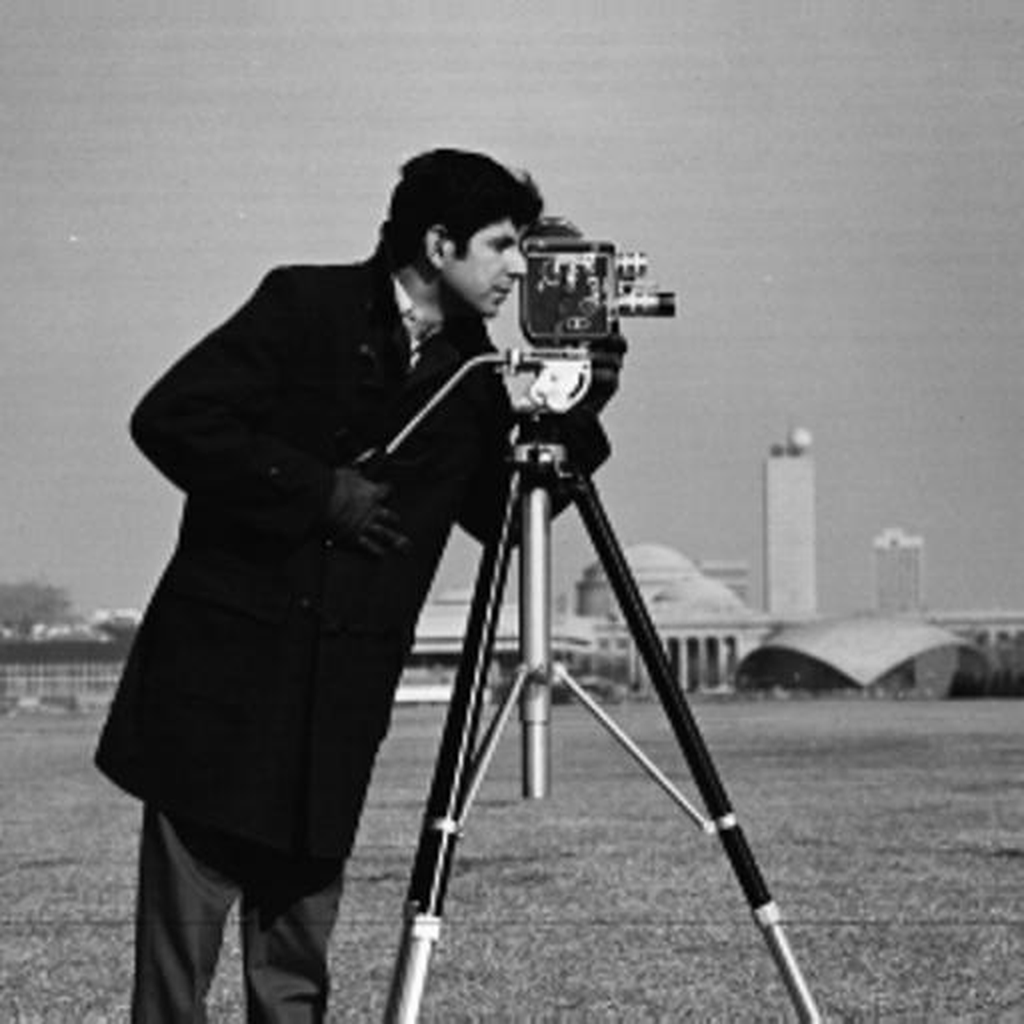

In [4]:
# Get the size of the image # type: ignore
# scaling factors
width,height=img.size
resized_img=img.resize((width*2,height*2),Image.Resampling.LANCZOS)

display(resized_img)

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
resized_img.save("task1_1_scaled.jpg")
resized_img.size

(1024, 1024)

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

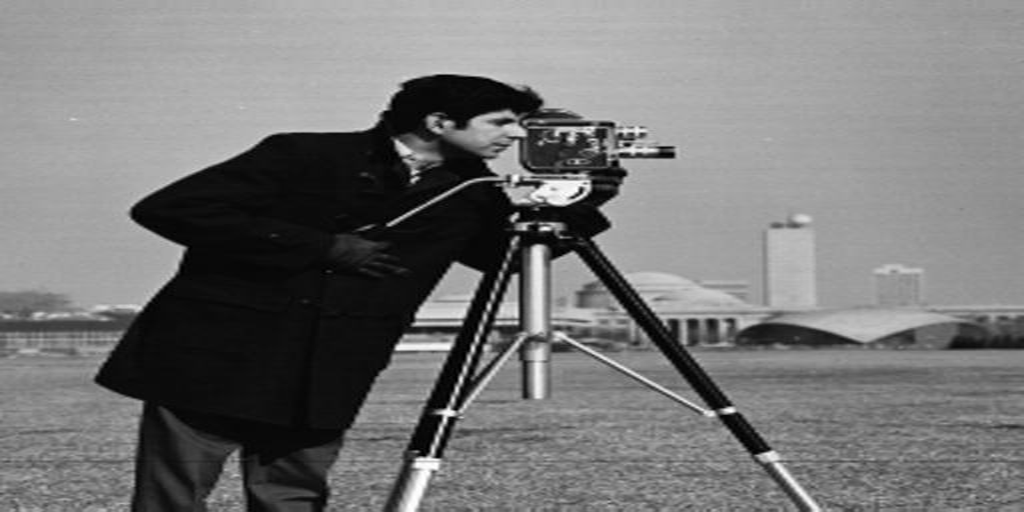

In [6]:
resized_img2=img.resize((width*2,height*1),Image.Resampling.LANCZOS)
display(resized_img2)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

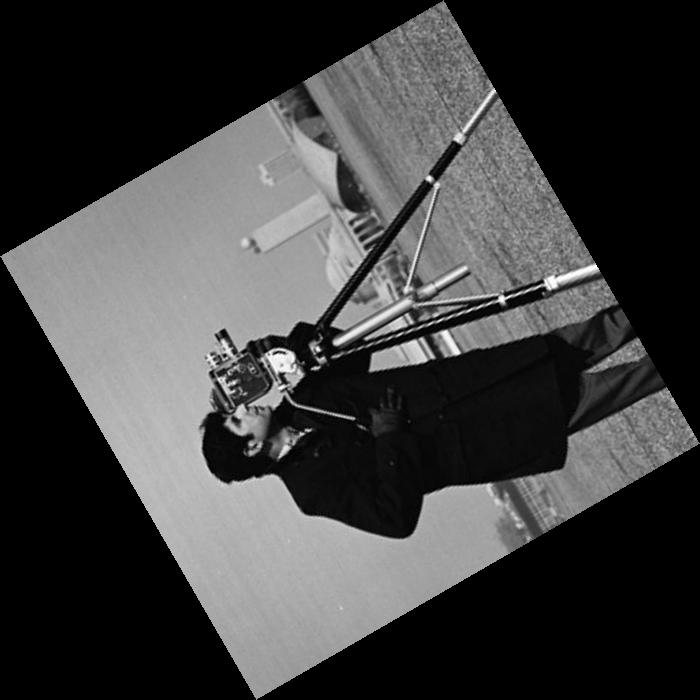

(700, 700)

In [7]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img=img.rotate(120,resample=3,expand=True)
display(rotated_img)
rotated_img.save("task1_2_rotated.jpg")
rotated_img.size

### 3. Shear

In [8]:
# -- c. Get the image dimensions ────────────────────


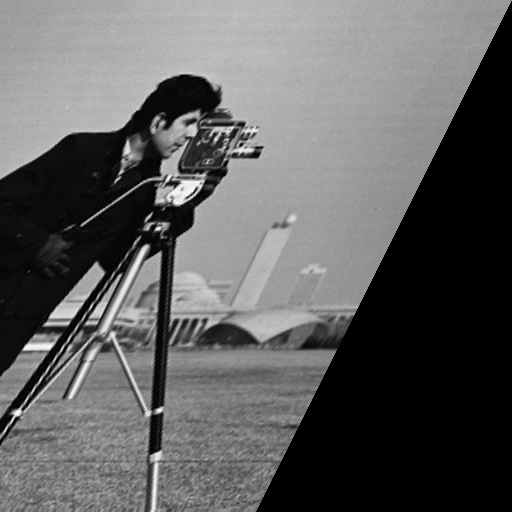

In [9]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
sher=img.transform((width, height),Image.AFFINE,
[1,0.5,0,
 0,1,0],
resample=Image.Resampling.BICUBIC)
display(sher)

In [10]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 

sher.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

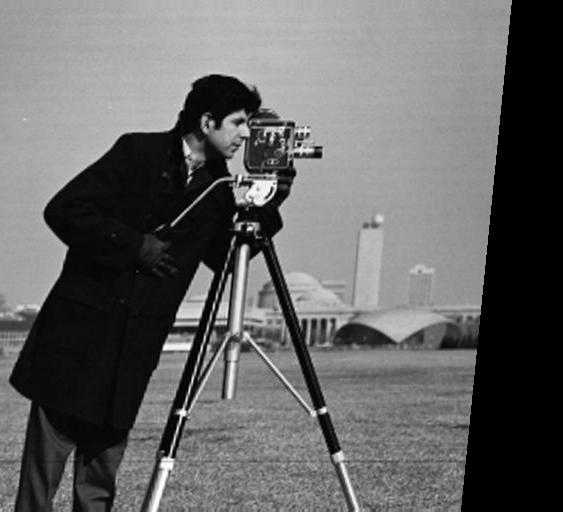

In [11]:
new_width=int(width*(1+0.1))
sher1=img.transform((new_width,height),Image.AFFINE,
[1,0.1,0,
 0,1,0],
resample=Image.BICUBIC)
display(sher1)

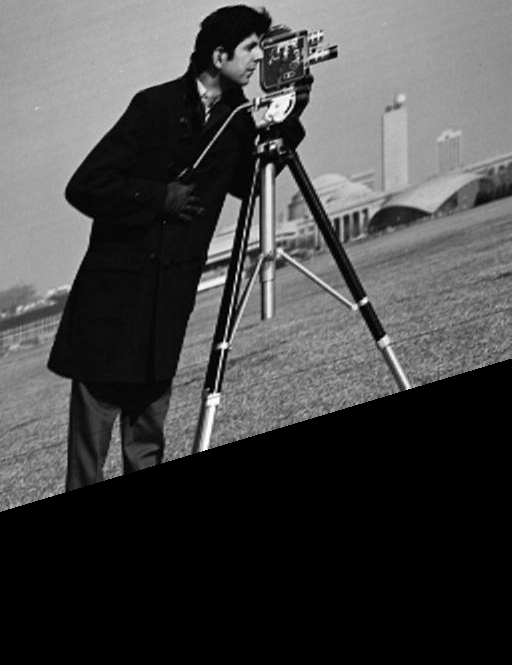

In [12]:
new_height=int(height*(1+0.3))
sher2=img.transform((width,new_height),Image.AFFINE,
[1,0,0,
 0.3,1,0],
resample=Image.BICUBIC)
display(sher2)

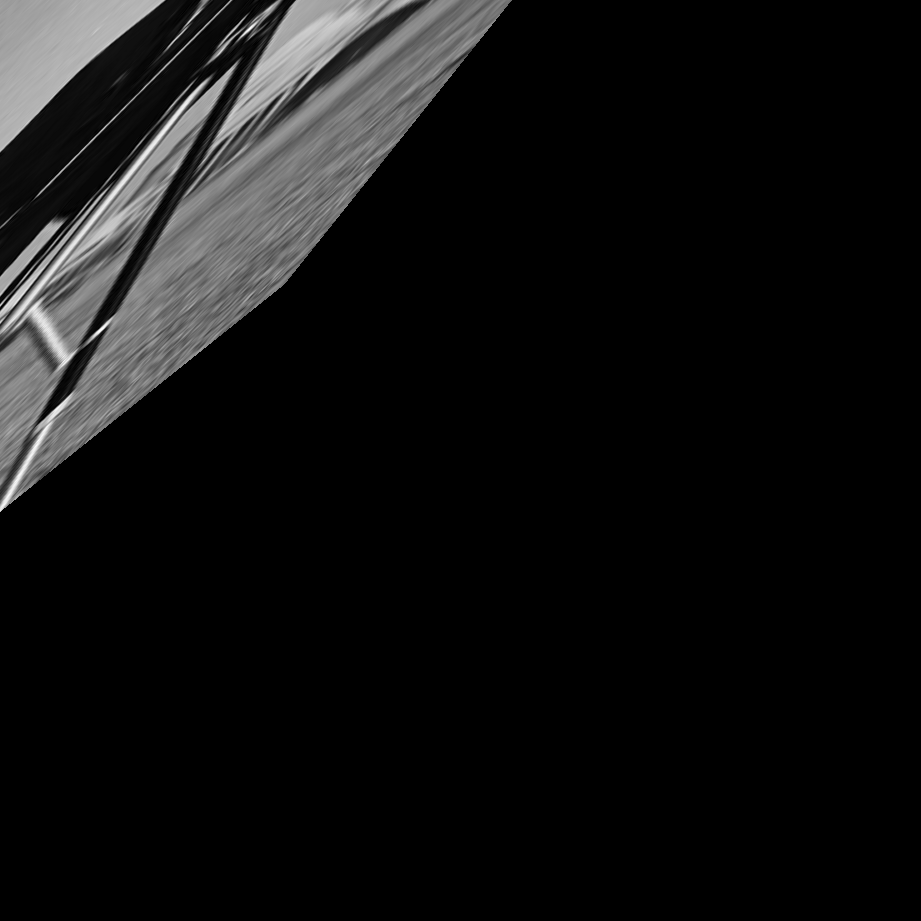

In [13]:
new_width=int(width*(1+0.8))
new_height=int(width*(1+0.8))
sher3=img.transform((new_width,new_height),Image.AFFINE,
[1,0.8,0,
 0.8,1,0],
resample=Image.BICUBIC)
display(sher3)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

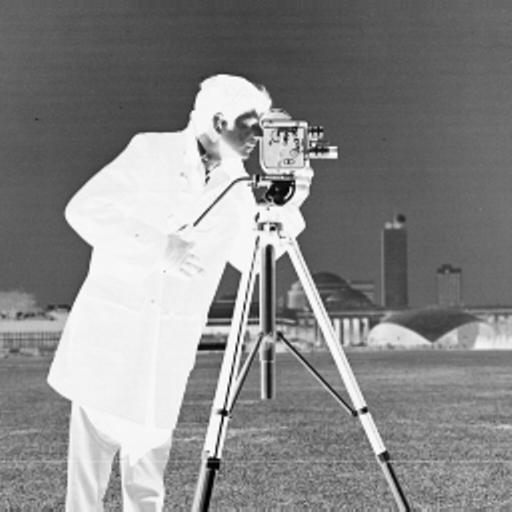

In [14]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr=np.array(img)
negative=Image.fromarray(255-arr)
display(negative)



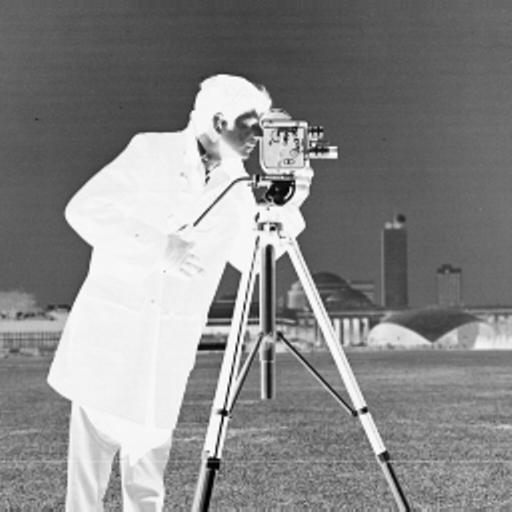

In [15]:
# Method 2: PIL's ImageOps
img_negative=ImageOps.invert(img)
display(img_negative)


/tmp/ipykernel_1624/1495017298.py:10: RuntimeWarning: divide by zero encountered in log
  log_arr= c*np.log(1+arr)
/tmp/ipykernel_1624/1495017298.py:11: RuntimeWarning: invalid value encountered in cast
  log_arr=Image.fromarray(np.uint8(log_arr))


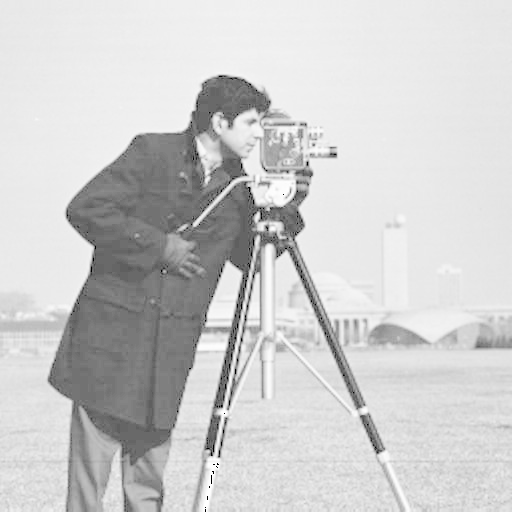

In [22]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c= 255/ np.log(1+255)

log_arr= c*np.log(1+arr)
log_arr=Image.fromarray(np.uint8(log_arr))
log_arr.save("log_transformmed.jpg")

display(log_arr)

# Apply the log transformation to each pixel


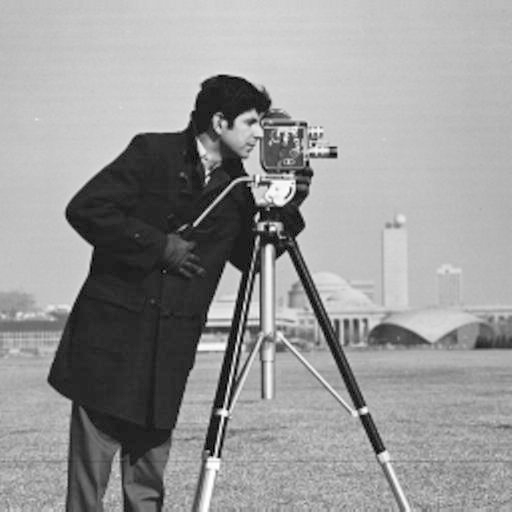

In [30]:

# ── 3. Power-law / Gamma corr6ection ───────────────
gamma_img=255*(arr/255)**0.6
gamma_img=Image.fromarray(np.uint8(gamma_img))
display(gamma_img)